In [1]:
#cell 1

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier

print("Environment ready.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SHAP:", shap.__version__)

Environment ready.
NumPy: 2.0.2
Pandas: 2.3.3
SHAP: 0.51.0


In [2]:
#cell 2

DATA_PATH = (
    "/kaggle/input/datasets/ealaxi/paysim1/"
    "PS_20174392719_1491204439457_log.csv"
)

RANDOM_STATE = 42

TRANSACTION_TYPES = [
    "CASH_IN",
    "CASH_OUT",
    "DEBIT",
    "PAYMENT",
    "TRANSFER",
]

print("Dataset path:")
print(DATA_PATH)

print("\nRandom state:", RANDOM_STATE)
print("Transaction types:", TRANSACTION_TYPES)

Dataset path:
/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv

Random state: 42
Transaction types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


In [3]:
#cell 3

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
#cell 4

print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFraud distribution:")
display(df["isFraud"].value_counts())

print("\nFraud rate:")
print(f"{df['isFraud'].mean() * 100:.4f}%")

Columns:
 1. step
 2. type
 3. amount
 4. nameOrig
 5. oldbalanceOrg
 6. newbalanceOrig
 7. nameDest
 8. oldbalanceDest
 9. newbalanceDest
10. isFraud
11. isFlaggedFraud

Data types:


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Duplicate rows: 0

Fraud distribution:


isFraud
0    6354407
1       8213
Name: count, dtype: int64


Fraud rate:
0.1291%


In [5]:
#cell 5

df_benchmark = df.copy()

# We retain oldbalanceOrg and oldbalanceDest here ONLY
# for the PaySim benchmark experiment.
#
# These fields will NOT be used in the production candidate.

DROP_BENCHMARK_COLUMNS = [
    "newbalanceOrig",
    "newbalanceDest",
    "nameOrig",
    "nameDest",
    "isFlaggedFraud",
]

df_benchmark = df_benchmark.drop(
    columns=DROP_BENCHMARK_COLUMNS,
    errors="ignore",
)

df_benchmark = df_benchmark.drop_duplicates()

df_benchmark = df_benchmark.dropna(
    subset=[
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "isFraud",
    ]
)

df_benchmark = (
    df_benchmark
    .sort_values("step")
    .reset_index(drop=True)
)

print("Benchmark cleaned shape:", df_benchmark.shape)

Benchmark cleaned shape: (6361742, 6)


In [6]:
#cell 6

def create_benchmark_features(dataframe: pd.DataFrame):
    data = dataframe.copy()

    data["hour"] = data["step"] % 24
    data["day"] = data["step"] // 24

    data["hour_sin"] = np.sin(
        2 * np.pi * data["hour"] / 24
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * data["hour"] / 24
    )

    data["log_amount"] = np.log1p(
        data["amount"]
    )

    data["amount_to_origin_balance"] = (
        data["amount"] /
        (data["oldbalanceOrg"] + 1.0)
    )

    data = pd.get_dummies(
        data,
        columns=["type"],
        prefix="type",
        dtype=int,
    )

    for transaction_type in TRANSACTION_TYPES:
        column = f"type_{transaction_type}"

        if column not in data.columns:
            data[column] = 0

    target = data["isFraud"].astype(int)

    features = [
        "step",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "hour",
        "day",
        "hour_sin",
        "hour_cos",
        "log_amount",
        "amount_to_origin_balance",
        "type_CASH_IN",
        "type_CASH_OUT",
        "type_DEBIT",
        "type_PAYMENT",
        "type_TRANSFER",
    ]

    X = data[features].copy()

    return X, target


X_benchmark, y_benchmark = create_benchmark_features(
    df_benchmark
)

print("Benchmark feature matrix:", X_benchmark.shape)
print("Benchmark target:", y_benchmark.shape)

print("\nFeatures:")
for feature in X_benchmark.columns:
    print(" -", feature)

Benchmark feature matrix: (6361742, 15)
Benchmark target: (6361742,)

Features:
 - step
 - amount
 - oldbalanceOrg
 - oldbalanceDest
 - hour
 - day
 - hour_sin
 - hour_cos
 - log_amount
 - amount_to_origin_balance
 - type_CASH_IN
 - type_CASH_OUT
 - type_DEBIT
 - type_PAYMENT
 - type_TRANSFER


In [7]:
#cell 7

from sklearn.model_selection import train_test_split

X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(
    X_benchmark,
    y_benchmark,
    test_size=0.30,
    stratify=y_benchmark,
    random_state=RANDOM_STATE,
)

X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(
    X_temp_b,
    y_temp_b,
    test_size=0.50,
    stratify=y_temp_b,
    random_state=RANDOM_STATE,
)

print("Benchmark split:")
print("Train:", X_train_b.shape)
print("Validation:", X_val_b.shape)
print("Test:", X_test_b.shape)

print(
    "\nTrain fraud rate:",
    f"{y_train_b.mean() * 100:.4f}%"
)

Benchmark split:
Train: (4453219, 15)
Validation: (954261, 15)
Test: (954262, 15)

Train fraud rate: 0.1289%


In [8]:
#cell 8

scale_pos_weight_b = (
    y_train_b.value_counts()[0] /
    y_train_b.value_counts()[1]
)

print(
    "Benchmark scale_pos_weight:",
    scale_pos_weight_b
)

benchmark_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_b,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

benchmark_model.fit(
    X_train_b,
    y_train_b,
    eval_set=[(X_val_b, y_val_b)],
    verbose=50,
)

print("\nBenchmark model trained.")

Benchmark scale_pos_weight: 775.0925409550366
[0]	validation_0-aucpr:0.76676
[50]	validation_0-aucpr:0.96369
[100]	validation_0-aucpr:0.96374
[150]	validation_0-aucpr:0.97001
[200]	validation_0-aucpr:0.97237
[250]	validation_0-aucpr:0.97403
[300]	validation_0-aucpr:0.97479
[350]	validation_0-aucpr:0.97507
[400]	validation_0-aucpr:0.97536
[450]	validation_0-aucpr:0.97529
[499]	validation_0-aucpr:0.97560

Benchmark model trained.


In [9]:
#cell 9

benchmark_test_proba = (
    benchmark_model
    .predict_proba(X_test_b)[:, 1]
)

benchmark_test_pred = (
    benchmark_test_proba >= 0.5
).astype(int)

benchmark_metrics = {
    "pr_auc": average_precision_score(
        y_test_b,
        benchmark_test_proba,
    ),
    "roc_auc": roc_auc_score(
        y_test_b,
        benchmark_test_proba,
    ),
    "precision": precision_score(
        y_test_b,
        benchmark_test_pred,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test_b,
        benchmark_test_pred,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test_b,
        benchmark_test_pred,
        zero_division=0,
    ),
}

print("PAYSIM BENCHMARK MODEL")
print("=" * 60)

for metric, value in benchmark_metrics.items():
    print(f"{metric.upper():<12}: {value:.6f}")

PAYSIM BENCHMARK MODEL
PR_AUC      : 0.973713
ROC_AUC     : 0.999902
PRECISION   : 0.641791
RECALL      : 0.978862
F1          : 0.775274


,importance
amount_to_origin_balance,0.582300
type_CASH_IN,0.175435
type_PAYMENT,0.091956
amount,0.024839
oldbalanceOrg,0.024625
log_amount,0.024340
type_TRANSFER,0.022675
type_CASH_OUT,0.020015
hour,0.013038
type_DEBIT,0.006656


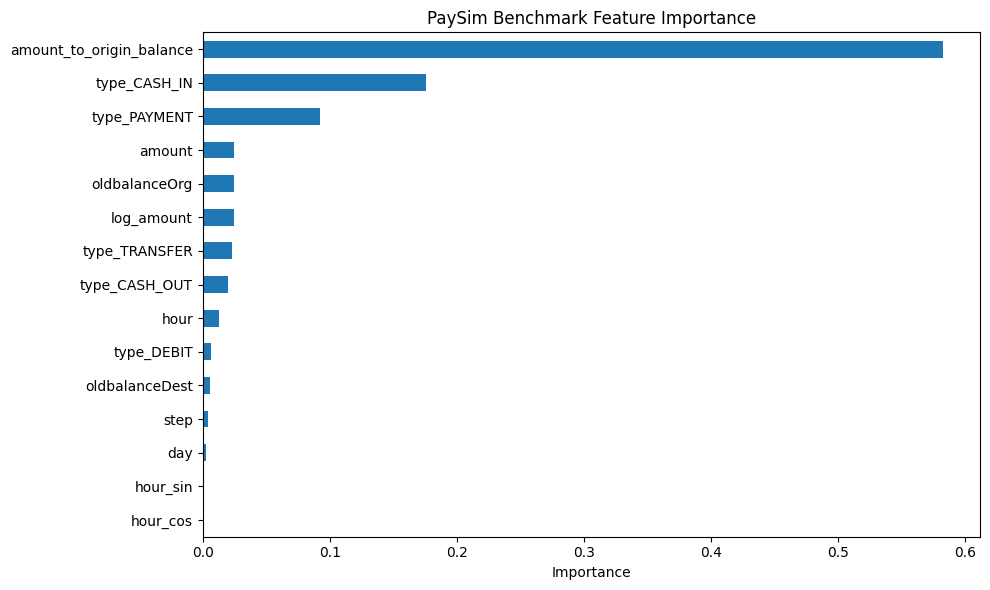

In [10]:
#cell 10

benchmark_importance = (
    pd.Series(
        benchmark_model.feature_importances_,
        index=X_benchmark.columns,
    )
    .sort_values(ascending=False)
)

display(
    benchmark_importance
    .to_frame("importance")
    .head(15)
)

plt.figure(figsize=(10, 6))

benchmark_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("PaySim Benchmark Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [11]:
#cell 11

BENCHMARK_ARTIFACT_PATH = (
    "/kaggle/working/"
    "fraudshield_paysim_benchmark.joblib"
)

benchmark_artifact = {
    "model": benchmark_model,
    "features": X_benchmark.columns.tolist(),
    "model_type": "XGBoost",
    "model_role": "PaySim benchmark",
    "dataset": "PaySim",
    "dataset_type": "synthetic",
    "split_type": "stratified_random",
    "random_state": RANDOM_STATE,
    "metrics": benchmark_metrics,
    "warning": (
        "Benchmark model uses PaySim balance-derived features "
        "and is not the production FraudShield transaction model."
    ),
}

joblib.dump(
    benchmark_artifact,
    BENCHMARK_ARTIFACT_PATH,
)

print("Benchmark artifact saved:")
print(BENCHMARK_ARTIFACT_PATH)

Benchmark artifact saved:
/kaggle/working/fraudshield_paysim_benchmark.joblib


In [12]:
#cell 12

SHAP_SAMPLE_SIZE = 5000

X_shap_b = X_test_b.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test_b)),
    random_state=RANDOM_STATE,
)

explainer_b = shap.TreeExplainer(
    benchmark_model
)

shap_values_b = explainer_b.shap_values(
    X_shap_b
)

print(
    "Benchmark SHAP calculated."
)

print(
    "SHAP sample shape:",
    X_shap_b.shape
)

Benchmark SHAP calculated.
SHAP sample shape: (5000, 15)


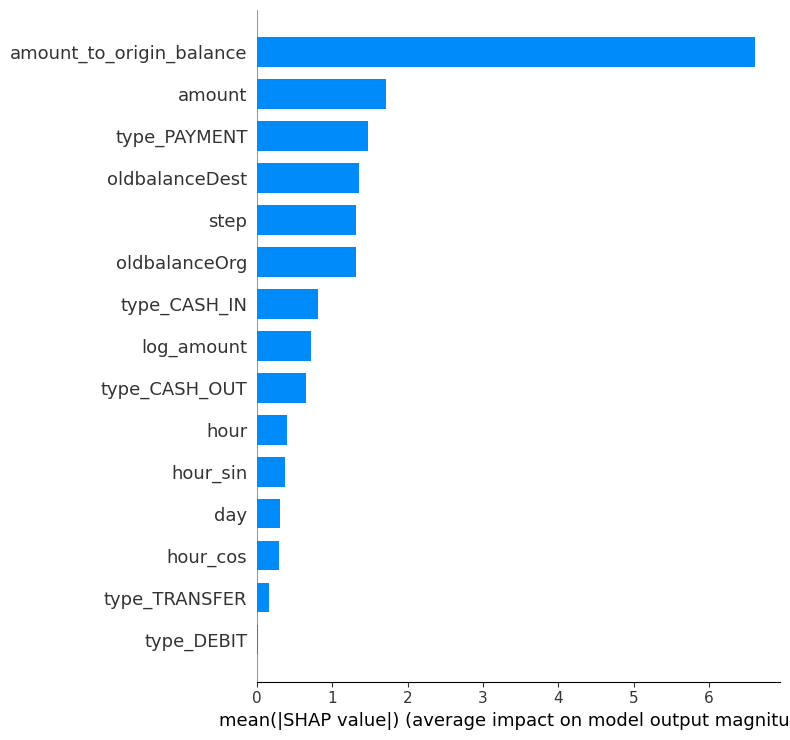

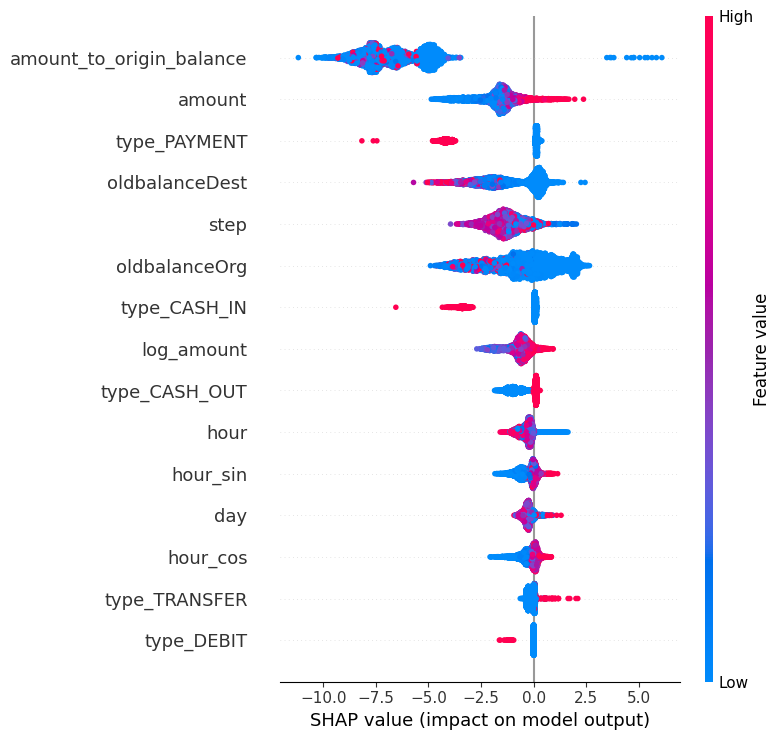

In [13]:
#cell 13

shap.summary_plot(
    shap_values_b,
    X_shap_b,
    plot_type="bar",
    max_display=15,
)

shap.summary_plot(
    shap_values_b,
    X_shap_b,
    max_display=15,
)

In [14]:
#cell 14

df_prod = df.copy()

# We intentionally retain nameDest temporarily.
# It is NOT used directly by the model.
# It is used only to construct causal recipient-history features.

DROP_PRODUCTION_COLUMNS = [
    "oldbalanceOrg",
    "oldbalanceDest",
    "newbalanceOrig",
    "newbalanceDest",
    "nameOrig",
    "isFlaggedFraud",
]

df_prod = df_prod.drop(
    columns=DROP_PRODUCTION_COLUMNS,
    errors="ignore",
)

df_prod = df_prod.drop_duplicates()

df_prod = df_prod.dropna(
    subset=[
        "step",
        "type",
        "amount",
        "nameDest",
        "isFraud",
    ]
)

# Critical: history must be generated chronologically.
df_prod = (
    df_prod
    .sort_values(
        ["step"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

print("Production candidate dataset:")
print(df_prod.shape)

print("\nRemaining columns:")
print(df_prod.columns.tolist())

Production candidate dataset:
(6361541, 5)

Remaining columns:
['step', 'type', 'amount', 'nameDest', 'isFraud']


In [15]:
#cell 15

unique_steps = np.sort(
    df_prod["step"].unique()
)

n_steps = len(unique_steps)

train_step_index = int(
    n_steps * 0.70
)

val_step_index = int(
    n_steps * 0.85
)

train_end_step = unique_steps[
    train_step_index - 1
]

val_end_step = unique_steps[
    val_step_index - 1
]

train_df = df_prod[
    df_prod["step"] <= train_end_step
].copy()

val_df = df_prod[
    (df_prod["step"] > train_end_step) &
    (df_prod["step"] <= val_end_step)
].copy()

test_df = df_prod[
    df_prod["step"] > val_end_step
].copy()

print("Chronological split:")
print(
    "Train:",
    train_df.shape,
    "| steps:",
    train_df["step"].min(),
    "to",
    train_df["step"].max(),
)

print(
    "Validation:",
    val_df.shape,
    "| steps:",
    val_df["step"].min(),
    "to",
    val_df["step"].max(),
)

print(
    "Test:",
    test_df.shape,
    "| steps:",
    test_df["step"].min(),
    "to",
    test_df["step"].max(),
)

print("\nFraud rates:")
print(
    "Train:",
    f"{train_df['isFraud'].mean() * 100:.4f}%"
)

print(
    "Validation:",
    f"{val_df['isFraud'].mean() * 100:.4f}%"
)

print(
    "Test:",
    f"{test_df['isFraud'].mean() * 100:.4f}%"
)

Chronological split:
Train: (6080929, 5) | steps: 1 to 520
Validation: (191147, 5) | steps: 521 to 631
Test: (89465, 5) | steps: 632 to 743

Fraud rates:
Train: 0.0951%
Validation: 0.6173%
Test: 1.3994%


In [16]:
#cell 15A

print("=" * 70)
print("CHRONOLOGICAL FRAUD DISTRIBUTION DIAGNOSTIC")
print("=" * 70)

for name, d in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    fraud_count = int(d["isFraud"].sum())
    legitimate_count = int((d["isFraud"] == 0).sum())
    total_count = len(d)
    fraud_rate = d["isFraud"].mean() * 100

    print(
        f"\n{name}"
        f"\n  Total transactions : {total_count:,}"
        f"\n  Fraud transactions : {fraud_count:,}"
        f"\n  Legitimate         : {legitimate_count:,}"
        f"\n  Fraud rate         : {fraud_rate:.4f}%"
    )

CHRONOLOGICAL FRAUD DISTRIBUTION DIAGNOSTIC

Train
  Total transactions : 6,080,929
  Fraud transactions : 5,781
  Legitimate         : 6,075,148
  Fraud rate         : 0.0951%

Validation
  Total transactions : 191,147
  Fraud transactions : 1,180
  Legitimate         : 189,967
  Fraud rate         : 0.6173%

Test
  Total transactions : 89,465
  Fraud transactions : 1,252
  Legitimate         : 88,213
  Fraud rate         : 1.3994%


In [17]:
#cell 15B

# Fraud count and transaction volume across simulation time

fraud_by_step = (
    df_prod
    .groupby("step")["isFraud"]
    .agg(
        fraud_count="sum",
        total_transactions="count",
    )
)

fraud_by_step["legitimate_count"] = (
    fraud_by_step["total_transactions"]
    - fraud_by_step["fraud_count"]
)

fraud_by_step["fraud_rate"] = (
    fraud_by_step["fraud_count"]
    / fraud_by_step["total_transactions"]
)

display(
    fraud_by_step.head()
)

print("\nSummary:")
display(
    fraud_by_step[
        [
            "fraud_count",
            "legitimate_count",
            "total_transactions",
            "fraud_rate",
        ]
    ].describe()
)

,fraud_count,total_transactions,legitimate_count,fraud_rate
step,,,,
1,16,2708,2692,0.005908
2,8,1014,1006,0.007890
3,4,552,548,0.007246
4,10,565,555,0.017699
5,6,665,659,0.009023



Summary:


,fraud_count,legitimate_count,total_transactions,fraud_rate
count,743.000000,743.000000,743.000000,743.000000
mean,11.053836,8550.912517,8561.966353,0.439253
std,4.998631,13386.317849,13386.552722,0.489562
min,0.000000,0.000000,2.000000,0.000000
25%,8.000000,0.000000,12.000000,0.000749
50%,10.000000,519.000000,529.000000,0.019157
75%,14.000000,12306.000000,12317.000000,1.000000
max,40.000000,51341.000000,51352.000000,1.000000


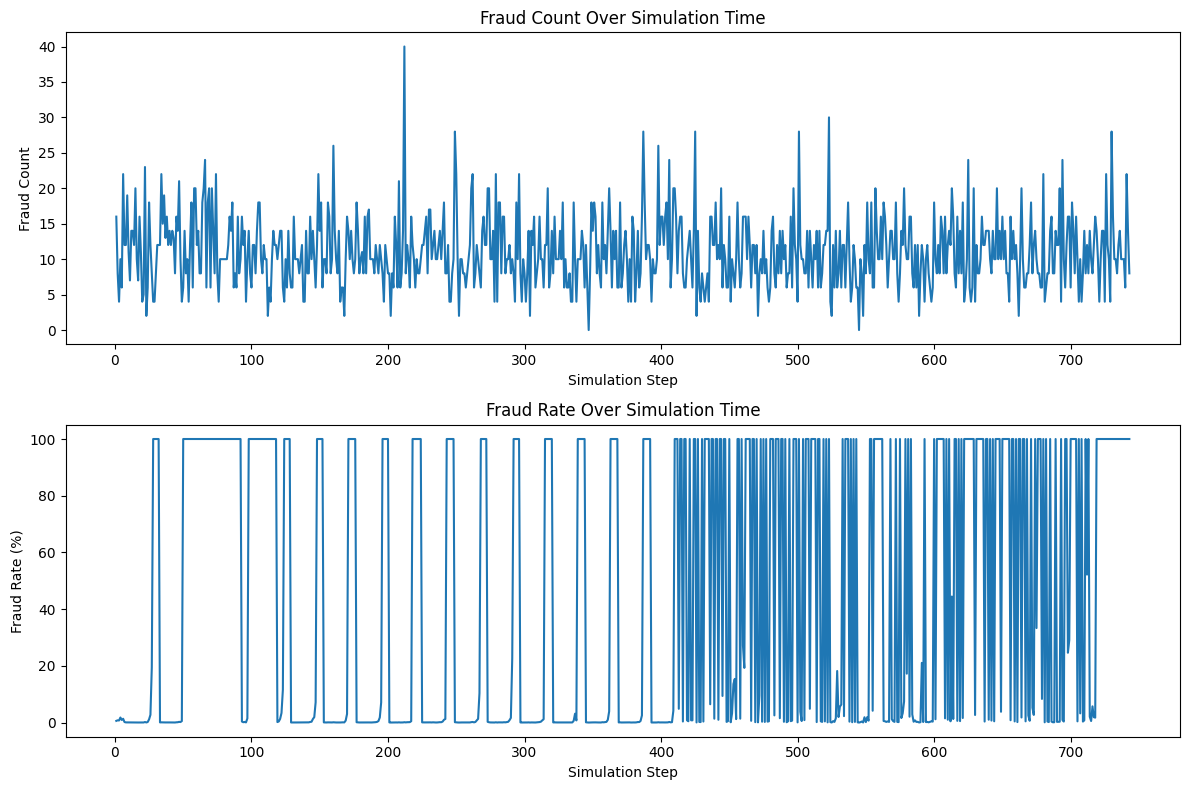

In [18]:
#cell 15C

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
)

axes[0].plot(
    fraud_by_step.index,
    fraud_by_step["fraud_count"],
)

axes[0].set_title(
    "Fraud Count Over Simulation Time"
)

axes[0].set_xlabel("Simulation Step")
axes[0].set_ylabel("Fraud Count")

axes[1].plot(
    fraud_by_step.index,
    fraud_by_step["fraud_rate"] * 100,
)

axes[1].set_title(
    "Fraud Rate Over Simulation Time"
)

axes[1].set_xlabel("Simulation Step")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [19]:
#cell 16

# Global amount statistics learned ONLY from training data

train_type_stats = (
    train_df
    .groupby("type")["amount"]
    .agg(
        type_mean="mean",
        type_median="median",
    )
)

global_amount_stats = {
    "mean": float(train_df["amount"].mean()),
    "median": float(train_df["amount"].median()),
    "std": float(train_df["amount"].std()),
    "p95": float(train_df["amount"].quantile(0.95)),
    "p99": float(train_df["amount"].quantile(0.99)),
}

print("Training-derived type statistics:")
display(train_type_stats)

print("\nTraining-derived global amount statistics:")
for key, value in global_amount_stats.items():
    print(f"{key}: {value:,.4f}")

Training-derived type statistics:


,type_mean,type_median
type,,
CASH_IN,168983.929145,143413.160
CASH_OUT,176040.309189,147386.920
DEBIT,5599.652909,3088.805
PAYMENT,13104.314265,9525.740
TRANSFER,901478.155862,490195.190



Training-derived global amount statistics:
mean: 178,672.2779
median: 75,091.0000
std: 595,859.1572
p95: 518,699.1240
p99: 1,601,959.5396


In [20]:
#cell 17

def add_causal_recipient_history(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
):
    """
    Build causal recipient-history features.

    A transaction may only use recipient information
    from STRICTLY EARLIER simulation steps.

    Transactions within the same PaySim step do not
    influence one another because 'step' represents
    an hourly simulation bucket.
    """

    combined = pd.concat(
        [
            train_df.assign(_split="train"),
            val_df.assign(_split="validation"),
            test_df.assign(_split="test"),
        ],
        ignore_index=True,
    )

    combined["_row_order"] = np.arange(len(combined))

    combined = (
        combined
        .sort_values(
            ["step", "_row_order"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    recipient_count = {}
    recipient_amount_sum = {}

    history_count = np.zeros(
        len(combined),
        dtype=np.int64,
    )

    history_amount_sum = np.zeros(
        len(combined),
        dtype=np.float64,
    )

    i = 0

    while i < len(combined):

        current_step = combined.loc[i, "step"]

        j = i

        while (
            j < len(combined)
            and combined.loc[j, "step"] == current_step
        ):
            j += 1

        # -----------------------------------------
        # Read ONLY completed previous steps.
        # -----------------------------------------
        for row_idx in range(i, j):

            recipient = combined.loc[
                row_idx,
                "nameDest",
            ]

            history_count[row_idx] = (
                recipient_count.get(
                    recipient,
                    0,
                )
            )

            history_amount_sum[row_idx] = (
                recipient_amount_sum.get(
                    recipient,
                    0.0,
                )
            )

        # -----------------------------------------
        # Only after the whole step has been
        # scored, update recipient state.
        # -----------------------------------------
        for row_idx in range(i, j):

            recipient = combined.loc[
                row_idx,
                "nameDest",
            ]

            amount = float(
                combined.loc[
                    row_idx,
                    "amount",
                ]
            )

            recipient_count[recipient] = (
                recipient_count.get(
                    recipient,
                    0,
                ) + 1
            )

            recipient_amount_sum[recipient] = (
                recipient_amount_sum.get(
                    recipient,
                    0.0,
                ) + amount
            )

        i = j

    combined["dest_prev_tx_count"] = (
        history_count
    )

    combined["dest_prev_amount_sum"] = (
        history_amount_sum
    )

    combined["dest_prev_mean_amount"] = (
        combined["dest_prev_amount_sum"]
        /
        combined["dest_prev_tx_count"]
        .replace(0, np.nan)
    )

    combined["dest_prev_mean_amount"] = (
        combined["dest_prev_mean_amount"]
        .fillna(
            global_amount_stats["median"]
        )
    )

    combined["amount_vs_dest_history"] = (
        combined["amount"]
        /
        (
            combined["dest_prev_mean_amount"]
            + 1.0
        )
    )

    combined["new_recipient"] = (
        (
            combined["dest_prev_tx_count"] == 0
        )
        .astype(int)
    )

    train_out = (
        combined[
            combined["_split"] == "train"
        ]
        .drop(
            columns=[
                "_split",
                "_row_order",
            ]
        )
        .copy()
    )

    val_out = (
        combined[
            combined["_split"] == "validation"
        ]
        .drop(
            columns=[
                "_split",
                "_row_order",
            ]
        )
        .copy()
    )

    test_out = (
        combined[
            combined["_split"] == "test"
        ]
        .drop(
            columns=[
                "_split",
                "_row_order",
            ]
        )
        .copy()
    )

    return (
        train_out,
        val_out,
        test_out,
    )


train_hist, val_hist, test_hist = (
    add_causal_recipient_history(
        train_df,
        val_df,
        test_df,
    )
)

print("Causal recipient history generated.")

display(
    train_hist[
        [
            "step",
            "nameDest",
            "amount",
            "dest_prev_tx_count",
            "dest_prev_mean_amount",
            "amount_vs_dest_history",
            "new_recipient",
        ]
    ].head(15)
)

Causal recipient history generated.


,step,nameDest,amount,dest_prev_tx_count,dest_prev_mean_amount,amount_vs_dest_history,new_recipient
0,1,M1979787155,9839.64,0,75091.0,0.131034,1
1,1,M2044282225,1864.28,0,75091.0,0.024827,1
2,1,C553264065,181.00,0,75091.0,0.002410,1
3,1,C38997010,181.00,0,75091.0,0.002410,1
4,1,M1230701703,11668.14,0,75091.0,0.155385,1
5,1,M573487274,7817.71,0,75091.0,0.104108,1
6,1,M408069119,7107.77,0,75091.0,0.094654,1
7,1,M633326333,7861.64,0,75091.0,0.104693,1
8,1,M1176932104,4024.36,0,75091.0,0.053592,1
9,1,C195600860,5337.77,0,75091.0,0.071083,1


In [21]:
#cell 18

def create_production_features(
    dataframe: pd.DataFrame,
    type_stats: pd.DataFrame,
    global_stats: dict,
):
    data = dataframe.copy()

    # -----------------------------
    # Time features
    # -----------------------------
    data["hour"] = data["step"] % 24
    data["day"] = data["step"] // 24

    data["hour_sin"] = np.sin(
        2 * np.pi * data["hour"] / 24
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * data["hour"] / 24
    )

    # -----------------------------
    # Amount features
    # -----------------------------
    data["log_amount"] = np.log1p(
        data["amount"]
    )

    # -----------------------------
    # Training-derived type statistics
    # -----------------------------
    data["type_mean_amount"] = (
        data["type"]
        .map(type_stats["type_mean"])
        .fillna(global_stats["mean"])
    )

    data["type_median_amount"] = (
        data["type"]
        .map(type_stats["type_median"])
        .fillna(global_stats["median"])
    )

    data["amount_vs_type_mean"] = (
        data["amount"]
        / (data["type_mean_amount"] + 1.0)
    )

    data["amount_vs_type_median"] = (
        data["amount"]
        / (data["type_median_amount"] + 1.0)
    )

    data["amount_vs_global_median"] = (
        data["amount"]
        / (global_stats["median"] + 1.0)
    )

    data["above_train_p95"] = (
        data["amount"] >= global_stats["p95"]
    ).astype(int)

    data["above_train_p99"] = (
        data["amount"] >= global_stats["p99"]
    ).astype(int)

    # -----------------------------
    # Recipient history
    # -----------------------------
    data["dest_prev_tx_count"] = (
        data["dest_prev_tx_count"]
        .fillna(0)
    )

    data["dest_prev_mean_amount"] = (
        data["dest_prev_mean_amount"]
        .fillna(global_stats["median"])
    )

    data["amount_vs_dest_history"] = (
        data["amount_vs_dest_history"]
        .fillna(1.0)
    )

    data["new_recipient"] = (
        data["new_recipient"]
        .fillna(1)
        .astype(int)
    )

    # Log-transform recipient history count.
    data["log_dest_prev_tx_count"] = (
        np.log1p(
            data["dest_prev_tx_count"]
        )
    )

    # -----------------------------
    # Transaction type
    # -----------------------------
    data = pd.get_dummies(
        data,
        columns=["type"],
        prefix="type",
        dtype=int,
    )

    for transaction_type in TRANSACTION_TYPES:
        column = f"type_{transaction_type}"

        if column not in data.columns:
            data[column] = 0

    # -----------------------------
    # Final model feature list
    # -----------------------------
    feature_columns = [
        "step",
        "amount",
        "hour",
        "day",
        "hour_sin",
        "hour_cos",
        "log_amount",

        "amount_vs_type_mean",
        "amount_vs_type_median",
        "amount_vs_global_median",

        "above_train_p95",
        "above_train_p99",

        # Recipient behavior
        "dest_prev_tx_count",
        "log_dest_prev_tx_count",
        "amount_vs_dest_history",
        "new_recipient",

        # Transaction type
        "type_CASH_IN",
        "type_CASH_OUT",
        "type_DEBIT",
        "type_PAYMENT",
        "type_TRANSFER",
    ]

    X = data[feature_columns].copy()

    y = None

    if "isFraud" in data.columns:
        y = data["isFraud"].astype(int)

    return X, y

In [22]:
#cell 19

X_train_p, y_train_p = create_production_features(
    train_hist,
    train_type_stats,
    global_amount_stats,
)

X_val_p, y_val_p = create_production_features(
    val_hist,
    train_type_stats,
    global_amount_stats,
)

X_test_p, y_test_p = create_production_features(
    test_hist,
    train_type_stats,
    global_amount_stats,
)

print("Production feature shapes:")
print("Train:", X_train_p.shape)
print("Validation:", X_val_p.shape)
print("Test:", X_test_p.shape)

print("\nProduction features:")

for feature in X_train_p.columns:
    print(" -", feature)

Production feature shapes:
Train: (6080929, 21)
Validation: (191147, 21)
Test: (89465, 21)

Production features:
 - step
 - amount
 - hour
 - day
 - hour_sin
 - hour_cos
 - log_amount
 - amount_vs_type_mean
 - amount_vs_type_median
 - amount_vs_global_median
 - above_train_p95
 - above_train_p99
 - dest_prev_tx_count
 - log_dest_prev_tx_count
 - amount_vs_dest_history
 - new_recipient
 - type_CASH_IN
 - type_CASH_OUT
 - type_DEBIT
 - type_PAYMENT
 - type_TRANSFER


In [23]:
#cell 20

assert list(X_train_p.columns) == list(
    X_val_p.columns
)

assert list(X_train_p.columns) == list(
    X_test_p.columns
)

assert not X_train_p.isnull().any().any()
assert not X_val_p.isnull().any().any()
assert not X_test_p.isnull().any().any()

print("Feature consistency checks passed.")
print("No missing values detected.")

print("\nFeature count:")
print(len(X_train_p.columns))

Feature consistency checks passed.
No missing values detected.

Feature count:
21


In [24]:
#cell 21

scale_pos_weight_p = (
    y_train_p.value_counts()[0]
    /
    y_train_p.value_counts()[1]
)

print(
    "Scale positive weight:",
    scale_pos_weight_p,
)

transaction_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_p,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=75,
)

transaction_model.fit(
    X_train_p,
    y_train_p,
    eval_set=[
        (X_val_p, y_val_p),
    ],
    verbose=50,
)

print("\nProduction candidate trained.")

print(
    "Best boosting round:",
    transaction_model.best_iteration,
)

print(
    "Best validation PR-AUC:",
    transaction_model.best_score,
)

Scale positive weight: 1050.8818543504583
[0]	validation_0-aucpr:0.23810
[50]	validation_0-aucpr:0.54516
[100]	validation_0-aucpr:0.59152
[150]	validation_0-aucpr:0.59869
[200]	validation_0-aucpr:0.60048
[247]	validation_0-aucpr:0.59536

Production candidate trained.
Best boosting round: 172
Best validation PR-AUC: 0.6052429953622602


In [42]:
#cell 22

val_proba_p = (
    transaction_model
    .predict_proba(X_val_p)[:, 1]
)

test_proba_p = (
    transaction_model
    .predict_proba(X_test_p)[:, 1]
)

val_pred_p = (
    val_proba_p >= 0.5
).astype(int)

test_pred_p = (
    test_proba_p >= 0.5
).astype(int)


def precision_at_percent(
    y_true,
    scores,
    percent,
):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = max(
        1,
        int(len(scores) * percent / 100),
    )

    top_indices = np.argsort(scores)[-k:]

    return float(
        y_true[top_indices].mean()
    )


production_metrics = {
    "validation_pr_auc": average_precision_score(
        y_val_p,
        val_proba_p,
    ),

    "validation_roc_auc": roc_auc_score(
        y_val_p,
        val_proba_p,
    ),

    "validation_precision": precision_score(
        y_val_p,
        val_pred_p,
        zero_division=0,
    ),

    "validation_recall": recall_score(
        y_val_p,
        val_pred_p,
        zero_division=0,
    ),

    "validation_f1": f1_score(
        y_val_p,
        val_pred_p,
        zero_division=0,
    ),

    "test_pr_auc": average_precision_score(
        y_test_p,
        test_proba_p,
    ),

    "test_roc_auc": roc_auc_score(
        y_test_p,
        test_proba_p,
    ),

    "test_precision": precision_score(
        y_test_p,
        test_pred_p,
        zero_division=0,
    ),

    "test_recall": recall_score(
        y_test_p,
        test_pred_p,
        zero_division=0,
    ),

    "test_f1": f1_score(
        y_test_p,
        test_pred_p,
        zero_division=0,
    ),

    "precision_at_top_0.1_percent":
        precision_at_percent(
            y_test_p.values,
            test_proba_p,
            0.1,
        ),

    "precision_at_top_0.5_percent":
        precision_at_percent(
            y_test_p.values,
            test_proba_p,
            0.5,
        ),

    "precision_at_top_1_percent":
        precision_at_percent(
            y_test_p.values,
            test_proba_p,
            1.0,
        ),

    "precision_at_top_2_percent":
        precision_at_percent(
            y_test_p.values,
            test_proba_p,
            2.0,
        ),
}

print("PRODUCTION TRANSACTION MODEL")
print("=" * 60)

for metric, value in production_metrics.items():
    print(
        f"{metric:<35}: {value:.6f}"
    )

PRODUCTION TRANSACTION MODEL
validation_pr_auc                  : 0.605271
validation_roc_auc                 : 0.973312
validation_precision               : 0.020740
validation_recall                  : 0.985593
validation_f1                      : 0.040626
test_pr_auc                        : 0.639812
test_roc_auc                       : 0.966669
test_precision                     : 0.044148
test_recall                        : 0.981629
test_f1                            : 0.084496
precision_at_top_0.1_percent       : 1.000000
precision_at_top_0.5_percent       : 0.926174
precision_at_top_1_percent         : 0.701342
precision_at_top_2_percent         : 0.462828


In [43]:
#cell 23

def precision_at_percent(
    y_true,
    scores,
    percent,
):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = max(
        1,
        int(len(scores) * percent / 100),
    )

    top_indices = np.argsort(
        scores
    )[-k:]

    return y_true[top_indices].mean()


for pct in [
    0.1,
    0.5,
    1.0,
    2.0,
    5.0,
]:
    precision_k = precision_at_percent(
        y_test_p.values,
        test_proba_p,
        pct,
    )

    print(
        f"Top {pct:>4.1f}% "
        f"precision: {precision_k:.4f}"
    )

Top  0.1% precision: 1.0000
Top  0.5% precision: 0.9262
Top  1.0% precision: 0.7013
Top  2.0% precision: 0.4628
Top  5.0% precision: 0.2312


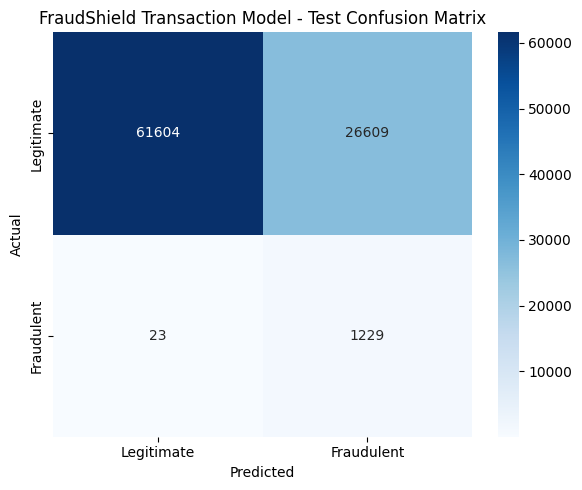

In [44]:
#cell 24

cm = confusion_matrix(
    y_test_p,
    test_pred_p,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Legitimate",
        "Fraudulent",
    ],
    yticklabels=[
        "Legitimate",
        "Fraudulent",
    ],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "FraudShield Transaction Model - Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [45]:
#cell 25

production_importance = (
    pd.Series(
        transaction_model.feature_importances_,
        index=X_train_p.columns,
    )
    .sort_values(ascending=False)
)

print("Production feature importance:")
display(
    production_importance
    .to_frame("importance")
)

Production feature importance:


,importance
type_TRANSFER,0.217743
type_PAYMENT,0.194340
type_CASH_IN,0.128889
amount_vs_dest_history,0.094194
type_CASH_OUT,0.085418
hour,0.046053
new_recipient,0.036017
log_dest_prev_tx_count,0.033778
dest_prev_tx_count,0.029977
amount_vs_type_mean,0.022215


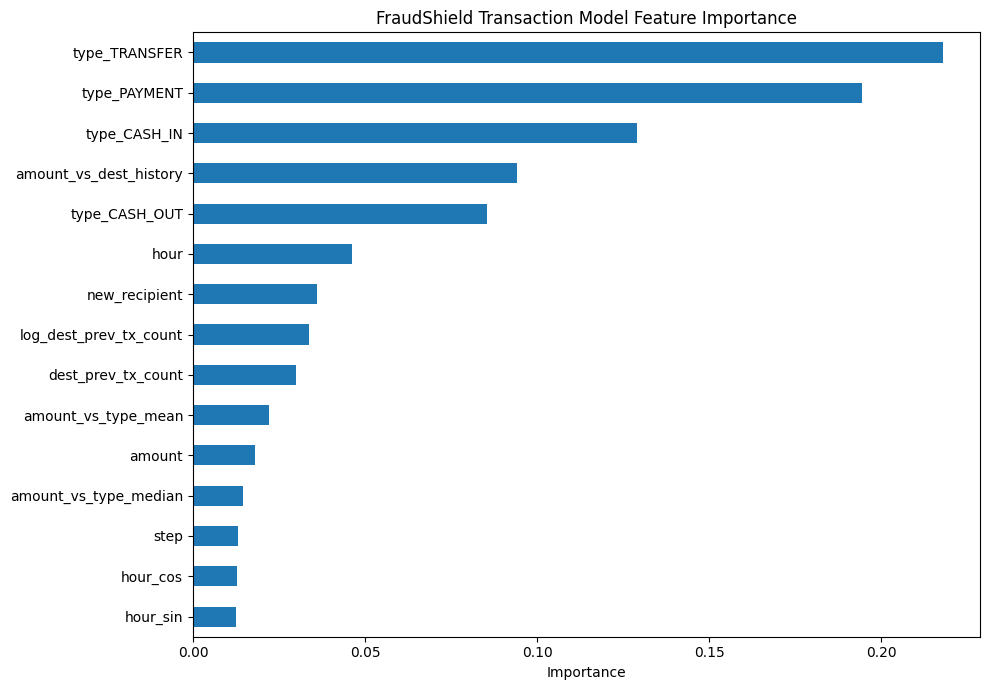

In [46]:
#cell 26

plt.figure(figsize=(10, 7))

production_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "FraudShield Transaction Model Feature Importance"
)

plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [47]:
#cell 27

SHAP_SAMPLE_SIZE = 5000

X_shap_p = X_test_p.sample(
    n=min(
        SHAP_SAMPLE_SIZE,
        len(X_test_p),
    ),
    random_state=RANDOM_STATE,
)

explainer_p = shap.TreeExplainer(
    transaction_model
)

shap_values_p = explainer_p.shap_values(
    X_shap_p
)

print("Production SHAP calculated.")
print(
    "SHAP sample shape:",
    X_shap_p.shape
)

Production SHAP calculated.
SHAP sample shape: (5000, 21)


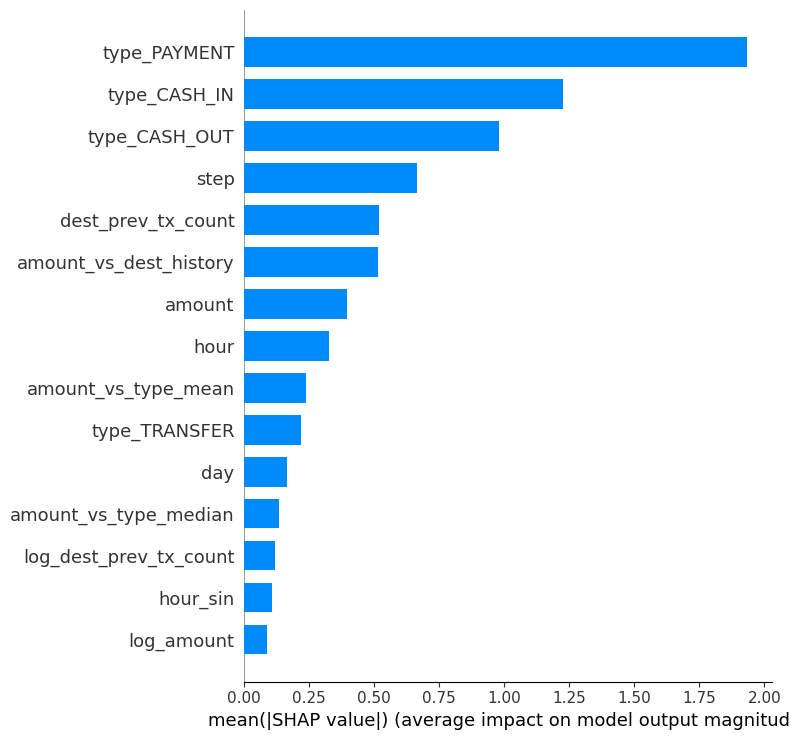

In [48]:
#cell 28

shap.summary_plot(
    shap_values_p,
    X_shap_p,
    plot_type="bar",
    max_display=15,
)

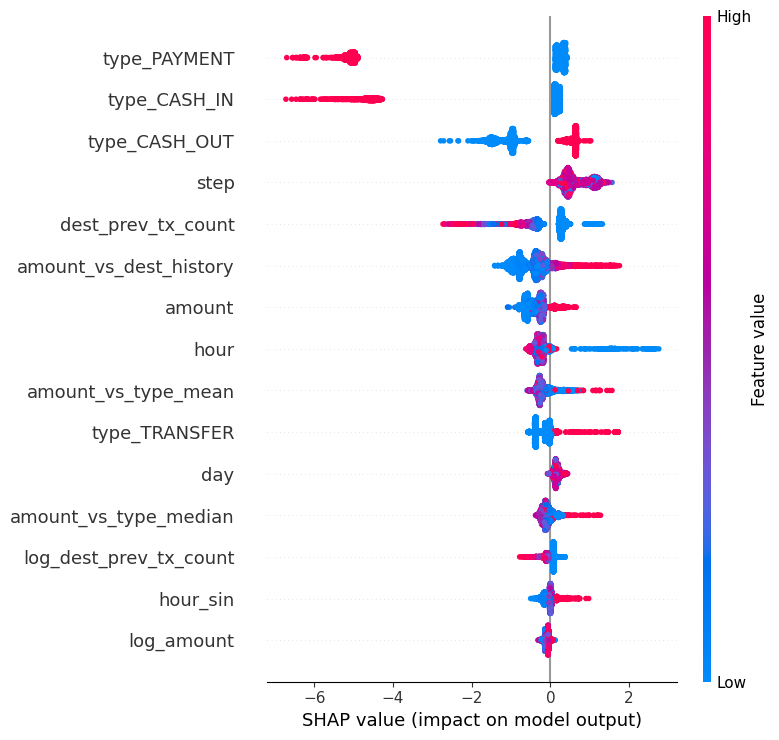

In [49]:
#cell 29

shap.summary_plot(
    shap_values_p,
    X_shap_p,
    max_display=15,
)

In [50]:
#cell 30

SHAP_DIR = (
    "/kaggle/working/"
    "fraudshield_transaction_shap"
)

os.makedirs(
    SHAP_DIR,
    exist_ok=True,
)

plt.figure()

shap.summary_plot(
    shap_values_p,
    X_shap_p,
    plot_type="bar",
    max_display=15,
    show=False,
)

plt.tight_layout()

SHAP_PATH = (
    f"{SHAP_DIR}/"
    "transaction_shap_feature_importance.png"
)

plt.savefig(
    SHAP_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.close()

print("SHAP plot saved:")
print(SHAP_PATH)

SHAP plot saved:
/kaggle/working/fraudshield_transaction_shap/transaction_shap_feature_importance.png


In [51]:
#cell 31

comparison = pd.DataFrame({
    "Model": [
        "PaySim Benchmark",
        "FraudShield Production Candidate",
    ],
    "PR-AUC": [
        benchmark_metrics["pr_auc"],
        production_metrics["test_pr_auc"],
    ],
    "ROC-AUC": [
        benchmark_metrics["roc_auc"],
        production_metrics["test_roc_auc"],
    ],
    "Precision": [
        benchmark_metrics["precision"],
        production_metrics["test_precision"],
    ],
    "Recall": [
        benchmark_metrics["recall"],
        production_metrics["test_recall"],
    ],
    "F1": [
        benchmark_metrics["f1"],
        production_metrics["test_f1"],
    ],
})

display(
    comparison.style.format({
        "PR-AUC": "{:.6f}",
        "ROC-AUC": "{:.6f}",
        "Precision": "{:.6f}",
        "Recall": "{:.6f}",
        "F1": "{:.6f}",
    })
)

,Model,PR-AUC,ROC-AUC,Precision,Recall,F1
0,PaySim Benchmark,0.973713,0.999902,0.641791,0.978862,0.775274
1,FraudShield Production Candidate,0.639812,0.966669,0.044148,0.981629,0.084496


In [52]:
#cell 32

PRODUCTION_ARTIFACT_PATH = (
    "/kaggle/working/"
    "fraudshield_transaction_model.joblib"
)

production_artifact = {
    "model": transaction_model,

    "model_type": "XGBoost",

    "model_role": (
        "FraudShield production transaction-risk model"
    ),

    "dataset": "PaySim",

    "dataset_type": (
        "synthetic mobile-money simulation"
    ),

    "split_type": "chronological",

    "random_state": RANDOM_STATE,

    "feature_schema_version": "transaction_v2",

    "preprocessing_version": (
        "causal_recipient_history_v1"
    ),

    # These fields are explicitly excluded from the
    # XGBoost model feature matrix.
    "excluded_model_features": [
        "oldbalanceOrg",
        "oldbalanceDest",
        "newbalanceOrig",
        "newbalanceDest",
        "nameOrig",
        "nameDest",
        "isFlaggedFraud",
    ],

    # nameDest is required temporarily at runtime
    # to construct causal recipient-history features.
    # It is NOT passed directly to XGBoost.
    "runtime_context_fields": [
        "nameDest",
    ],

    "features": X_train_p.columns.tolist(),

    "feature_engineering": [
        "hour",
        "day",
        "hour_sin",
        "hour_cos",
        "log_amount",
        "amount_vs_type_mean",
        "amount_vs_type_median",
        "amount_vs_global_median",
        "above_train_p95",
        "above_train_p99",
        "destination_transaction_count",
        "destination_previous_mean_amount",
        "amount_vs_destination_history",
        "new_recipient",
        "log_destination_transaction_count",
        "one_hot_transaction_type",
    ],

    "training_statistics": {
        "type_stats": train_type_stats.to_dict(),
        "global_amount_stats": global_amount_stats,
    },

    "recipient_history_definition": {
        "history_is_causal": True,
        "same_step_transactions_excluded": True,
        "history_source": "nameDest",
        "current_transaction_included": False,
    },

    "metrics": production_metrics,

    "output_semantics": {
        "model_output": (
            "fraud_probability between 0 and 1"
        ),
        "backend_output": (
            "transaction_risk between 0 and 100"
        ),
        "threshold": (
            "Not fixed here; risk thresholds are "
            "handled by the fusion engine."
        ),
    },
}

joblib.dump(
    production_artifact,
    PRODUCTION_ARTIFACT_PATH,
)

print("Production transaction artifact saved:")
print(PRODUCTION_ARTIFACT_PATH)

print("\nArtifact summary:")
print("Model role:", production_artifact["model_role"])
print(
    "Feature schema:",
    production_artifact["feature_schema_version"],
)
print(
    "Preprocessing:",
    production_artifact["preprocessing_version"],
)
print(
    "Number of model features:",
    len(production_artifact["features"]),
)

Production transaction artifact saved:
/kaggle/working/fraudshield_transaction_model.joblib

Artifact summary:
Model role: FraudShield production transaction-risk model
Feature schema: transaction_v2
Preprocessing: causal_recipient_history_v1
Number of model features: 21


In [53]:
#cell 33

loaded_artifact = joblib.load(
    PRODUCTION_ARTIFACT_PATH
)

print("ARTIFACT VERIFICATION")
print("=" * 60)

print(
    "Model type:",
    type(
        loaded_artifact["model"]
    ).__name__,
)

print(
    "Model role:",
    loaded_artifact["model_role"],
)

print(
    "Feature count:",
    len(
        loaded_artifact["features"]
    ),
)

print("\nFeatures:")

for feature in loaded_artifact["features"]:
    print(" -", feature)

print("\nExcluded model features:")

for feature in loaded_artifact[
    "excluded_model_features"
]:
    print(" -", feature)

print("\nRuntime context fields:")

for field in loaded_artifact[
    "runtime_context_fields"
]:
    print(" -", field)

print("\nFeature schema version:")
print(
    loaded_artifact[
        "feature_schema_version"
    ]
)

print("\nPreprocessing version:")
print(
    loaded_artifact[
        "preprocessing_version"
    ]
)

print("\nArtifact loaded successfully.")

ARTIFACT VERIFICATION
Model type: XGBClassifier
Model role: FraudShield production transaction-risk model
Feature count: 21

Features:
 - step
 - amount
 - hour
 - day
 - hour_sin
 - hour_cos
 - log_amount
 - amount_vs_type_mean
 - amount_vs_type_median
 - amount_vs_global_median
 - above_train_p95
 - above_train_p99
 - dest_prev_tx_count
 - log_dest_prev_tx_count
 - amount_vs_dest_history
 - new_recipient
 - type_CASH_IN
 - type_CASH_OUT
 - type_DEBIT
 - type_PAYMENT
 - type_TRANSFER

Excluded model features:
 - oldbalanceOrg
 - oldbalanceDest
 - newbalanceOrig
 - newbalanceDest
 - nameOrig
 - nameDest
 - isFlaggedFraud

Runtime context fields:
 - nameDest

Feature schema version:
transaction_v2

Preprocessing version:
causal_recipient_history_v1

Artifact loaded successfully.


In [54]:
#cell 34

loaded_model = loaded_artifact["model"]

sample_X = X_test_p.head(10)

sample_probabilities = (
    loaded_model
    .predict_proba(sample_X)[:, 1]
)

sample_risk = (
    sample_probabilities * 100
)

results = pd.DataFrame({
    "fraud_probability": sample_probabilities,
    "transaction_risk": sample_risk,
})

display(results)

,fraud_probability,transaction_risk
0,0.995681,99.568108
1,0.989599,98.959938
2,0.996241,99.624107
3,0.984893,98.489319
4,0.995432,99.543152
5,0.980251,98.025078
6,0.994197,99.419678
7,0.981161,98.116135
8,0.990397,99.039711
9,0.850982,85.098228


In [55]:
#cell 35

FINAL_SUMMARY = {
    "benchmark_model": {
        "role": "PaySim benchmark",
        **benchmark_metrics,
    },
    "production_model": {
        "role": "FraudShield transaction-risk model",
        **production_metrics,
    },
}

SUMMARY_PATH = (
    "/kaggle/working/"
    "fraudshield_transaction_evaluation.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FINAL_SUMMARY,
        file,
        indent=4,
    )

print("Evaluation summary saved:")
print(SUMMARY_PATH)

Evaluation summary saved:
/kaggle/working/fraudshield_transaction_evaluation.json


In [57]:
#cell 36

print("=" * 70)
print("FRAUDSHIELD NOTEBOOK 02 COMPLETE")
print("=" * 70)

print("\nBenchmark:")
print(
    f"PR-AUC = {benchmark_metrics['pr_auc']:.6f}"
)

print("\nProduction candidate:")
print(
    f"PR-AUC = {production_metrics['test_pr_auc']:.6f}"
)

print(
    f"ROC-AUC = {production_metrics['test_roc_auc']:.6f}"
)

print(
    f"Precision = {production_metrics['test_precision']:.6f}"
)

print(
    f"Recall = {production_metrics['test_recall']:.6f}"
)

print(
    f"F1 = {production_metrics['test_f1']:.6f}"
)

print("\nArtifacts:")
print(
    "Benchmark:",
    BENCHMARK_ARTIFACT_PATH,
)

print(
    "Production:",
    PRODUCTION_ARTIFACT_PATH,
)


FRAUDSHIELD NOTEBOOK 02 COMPLETE

Benchmark:
PR-AUC = 0.973713

Production candidate:
PR-AUC = 0.639812
ROC-AUC = 0.966669
Precision = 0.044148
Recall = 0.981629
F1 = 0.084496

Artifacts:
Benchmark: /kaggle/working/fraudshield_paysim_benchmark.joblib
Production: /kaggle/working/fraudshield_transaction_model.joblib
